In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/loan.csv")

df["Loan_Status"] = df["Loan_Status"].map({"Y":0, "N":1})

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,1
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,0


In [3]:
X = df.drop(columns=["Loan_Status", "Loan_ID"])
y = df["Loan_Status"]

In [5]:
numeric_features = X.select_dtypes(include=["number"]).columns

categorical_features = X.select_dtypes(include=["object", "string"]).columns

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numeric: 5
Categorical: 6


In [6]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_probs = log_model.predict_proba(X_test)[:,1]
log_preds = log_model.predict(X_test)

print("Logistic Regression")

print("ROC-AUC:", roc_auc_score(y_test, log_probs))
print("PR-AUC :", average_precision_score(y_test, log_probs))
print("F1     :", f1_score(y_test, log_preds))
print("Recall :", recall_score(y_test, log_preds))

Logistic Regression
ROC-AUC: 0.7647058823529411
PR-AUC : 0.6930976880977213
F1     : 0.6101694915254238
Recall : 0.47368421052631576


In [9]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_probs = rf_model.predict_proba(X_test)[:,1]
rf_preds = rf_model.predict(X_test)

print("Random Forest")

print("ROC-AUC:", roc_auc_score(y_test, rf_probs))
print("PR-AUC :", average_precision_score(y_test, rf_probs))
print("F1     :", f1_score(y_test, rf_preds))
print("Recall :", recall_score(y_test, rf_preds))

Random Forest
ROC-AUC: 0.7320433436532507
PR-AUC : 0.6746360158633609
F1     : 0.5846153846153846
Recall : 0.5


In [10]:
threshold = 0.35

threshold_preds = (rf_probs >= threshold).astype(int)

print("Threshold:", threshold)

print("Precision:", precision_score(y_test, threshold_preds))
print("Recall   :", recall_score(y_test, threshold_preds))
print("F1       :", f1_score(y_test, threshold_preds))

Threshold: 0.35
Precision: 0.5476190476190477
Recall   : 0.6052631578947368
F1       : 0.575


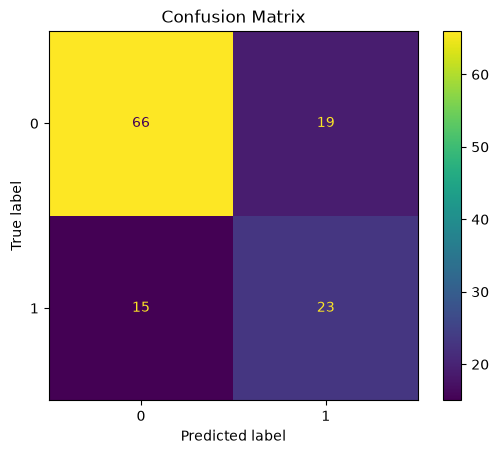

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    threshold_preds
)

plt.title("Confusion Matrix")

plt.savefig("../reports/figures/confusion_matrix.png")

plt.show()

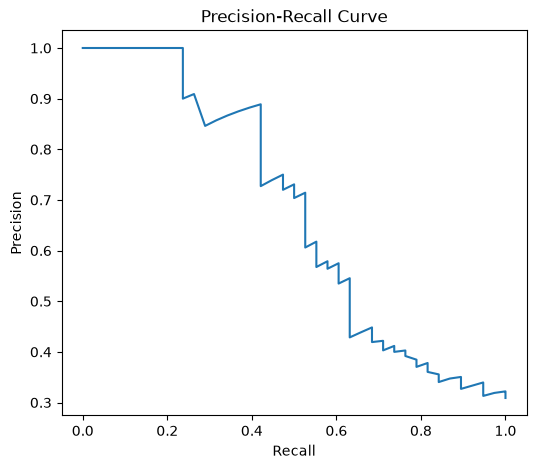

In [12]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_probs
)

plt.figure(figsize=(6,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.savefig("../reports/figures/pr_curve.png")

plt.show()

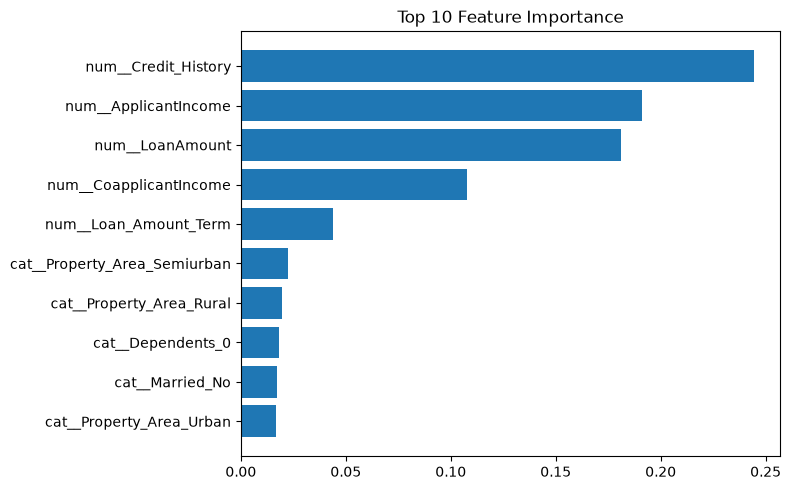

In [13]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance")

plt.tight_layout()

plt.savefig("../reports/figures/feature_importance.png")

plt.show()

In [14]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, rf_probs)
    ],
    "PR-AUC": [
        average_precision_score(y_test, log_probs),
        average_precision_score(y_test, rf_probs)
    ],
    "F1": [
        f1_score(y_test, log_preds),
        f1_score(y_test, rf_preds)
    ],
    "Recall": [
        recall_score(y_test, log_preds),
        recall_score(y_test, rf_preds)
    ]
})

results

,Model,ROC-AUC,PR-AUC,F1,Recall
0,Logistic Regression,0.764706,0.693098,0.610169,0.473684
1,Random Forest,0.732043,0.674636,0.584615,0.500000
